# Analyzing Pet Adoption Trends and Factors - Gaby Castellanos

### Project Overview
Animals shelters are currently facing an overcrowding crisis as many pets are being surrounded to animal shelters but not enough people are adopting. This leads some to resort to controversial methods to reduce overcrowding. It's often unclear which pet characteristics and circumstances are most influential on whether a pet is adopted or not. This project aims to analyze pet shelter data to identify the most common key factors that affect the likelihood of a pet being adopted. The factors relating to a pet's amount of time spent in a shelter will also be examined. The variables included in the dataset are PetID, PetType, Breed, AgeMonths, Color, Size, Weightkg, Vaccinated, HealthCondition, TimeInShelterDays, AdoptionFee, PreviousOwner, and AdoptionLikelihood. With the exploration and analysis of the dataset, hopefully the key factors will reveal what is needed to improve adoption outcomes. This project will be done individually.

In [51]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Overview and Information

In [52]:
# Import packages, load the pet_adoption_data dataset, and view the data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

PetAdoptionData = pd.read_csv('/content/drive/My Drive/Colab Notebooks/pet_adoption_data.csv')
PetAdoptionData.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


In [53]:
# Look over the data information and descriptive statistics
PetAdoptionData.info()
PetAdoptionData.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,1503.000000,92.279522,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,52.148363,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,1.000000,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,48.000000,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,94.000000,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,138.000000,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000
max,2506.000000,179.000000,29.995628,1.000000,1.000000,89.000000,499.000000,1.000000,1.000000


### Data Cleaning

In [96]:
# Check for missing values
PetAdoptionData.isnull().sum()

# no missing values

,0
PetID,0
PetType,0
Breed,0
AgeMonths,0
Color,0
Size,0
WeightKg,0
Vaccinated,0
HealthCondition,0
TimeInShelterDays,0


In [97]:
# Check for outliers
Q1 = PetAdoptionData['TimeInShelterDays'].quantile(0.25)
Q3 = PetAdoptionData['TimeInShelterDays'].quantile(0.75)
IQR = Q3 - Q1

outliers = PetAdoptionData[((PetAdoptionData['TimeInShelterDays']
                             < (Q1 - 1.5 * IQR)) |
                              (PetAdoptionData['TimeInShelterDays'] >
                               (Q3 + 1.5 * IQR)))]
outliers # No outliers

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood


### Visualizations and Searching for Relationships

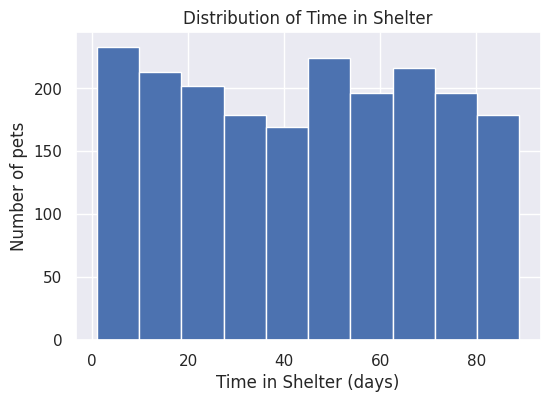

In [98]:
# Visualization of the TimeInShelterDays
plt.figure(figsize=(6, 4))
plt.hist(PetAdoptionData['TimeInShelterDays'])
plt.xlabel('Time in Shelter (days)')
plt.ylabel('Number of pets')
plt.title('Distribution of Time in Shelter')
plt.show()

# The distribution of time in shelter appears to be fairly distributed,
# which suggests that longer and shorter stays occur with similar frequency.
# Adoption time may depend on a combination of factors.

Text(0.5, 1.0, 'Vaccinated vs. AdoptionLikelihood')

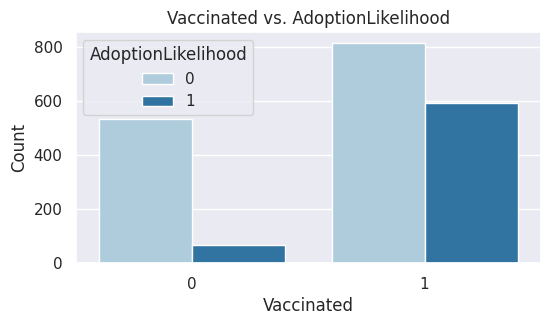

In [100]:
# Vaccinated vs. AdoptionLikelihood
sns.set(rc={'figure.figsize':(6, 3)})
sns.countplot(x='Vaccinated', hue='AdoptionLikelihood',
              data=PetAdoptionData, palette='Paired')
plt.xlabel('Vaccinated')
plt.ylabel('Count')
plt.title('Vaccinated vs. AdoptionLikelihood')

# The count plot shows that vaccinated pets tend to have a higher number of
# successful adoptions compared to unvaccinated pets. While both groups include
# a high number of pets that weren't adopted, the proportion of adopted pets is
# noticeably higher among those that are vaccinated.

Text(0.5, 1.0, 'Size vs. Adoption Likelihood')

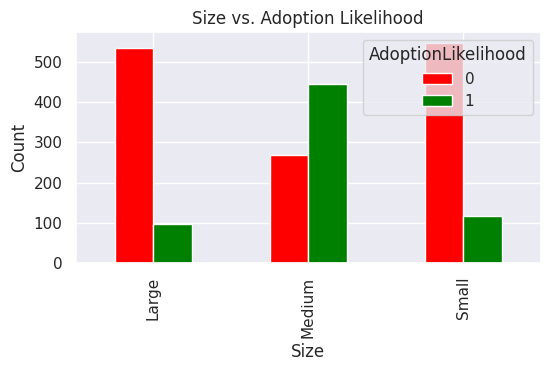

In [92]:
# Size vs Adoption Likelihood
PetAdoptionData.groupby(
    ['Size', 'AdoptionLikelihood']).size().unstack().plot(kind="bar"
    , color=['red', 'green'], figsize=(6, 3))

plt.xlabel('Size')
plt.ylabel('Count')
plt.title('Size vs. Adoption Likelihood')

# There is a high number of large and small pets that don't get adopted while
# there is a lower number for medium pets. They also have the highest adoption
# numbers. This suggests that medium sized pets are the most desirable size for
# pets.

Text(0.5, 1.0, 'Previous Owner vs. Adoption Likelihood')

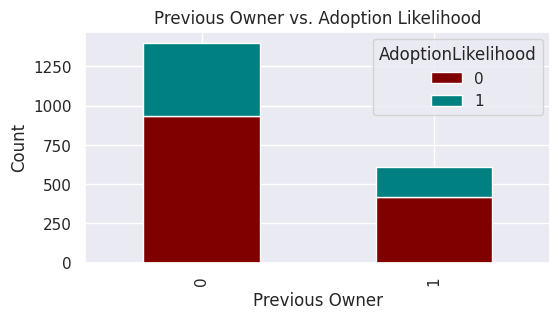

In [93]:
# Previous Owner vs Adoption Likelihood
PetAdoptionData.groupby(
    ['PreviousOwner', 'AdoptionLikelihood']).size().unstack().plot(kind="bar"
    , stacked=True, color=['maroon', 'teal'], figsize=(6, 3))
plt.xlabel('Previous Owner')
plt.ylabel('Count')
plt.title('Previous Owner vs. Adoption Likelihood')

# The stacked bar chart shows that pets without previous owners overall make up
# a larger portion of the dataset and they make up a larger amount of adoptions.
# Out of the pets that do get adopted, not having a previous owner seems to be
# favorable. The chances of pets with previous owners of being adopted is about
# 1/3 of their likelihood of not being adopted.

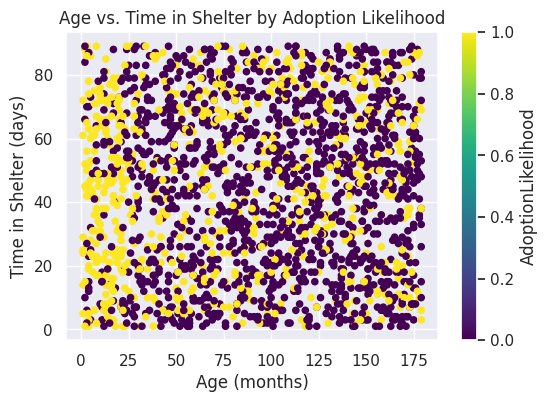

In [94]:
# Age vs Time in Shelter by Adoption Likelihood
PetAdoptionData.plot(kind='scatter', x='AgeMonths', y='TimeInShelterDays',
                     c='AdoptionLikelihood', colormap='viridis', figsize=(6, 4))
plt.xlabel('Age (months)')
plt.ylabel('Time in Shelter (days)')
plt.title('Age vs. Time in Shelter by Adoption Likelihood')
plt.show()

# The scatter plot shows almost no correlation between a pet's age and their
# time in the shelter. However, the yellow dots being slightly more visible on
# the left side of the scatter plot may suggest that pets under 25 months old
# have a higher adoption likelihood.

The TimeInShelterDays variable represents the number of days a pet remained in the shelter at the time the data was collected. However, the dataset doesn't make it clear if they were all adopted at the end of the time.

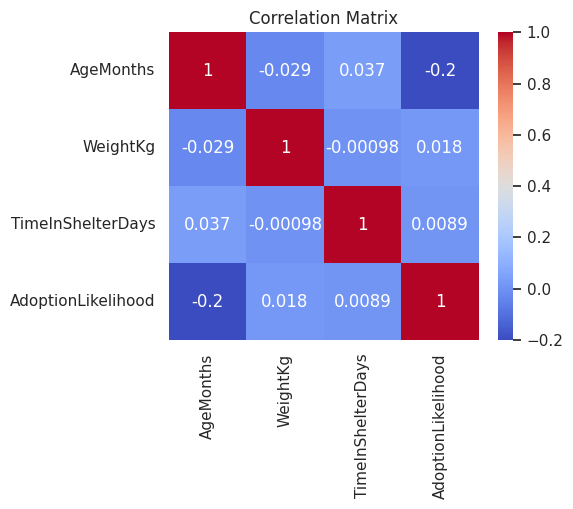

In [104]:
# Correlation Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(PetAdoptionData[['AgeMonths', 'WeightKg',
                             'TimeInShelterDays', 'AdoptionLikelihood']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows the relationships between a pet's age, weight, time in the shelter, and adoption likelihood. All the values are close to 0, displaying weak relationships. When adoption likelihood is factored in, the strongest correlation is shown between adoption likelihood and age, which is -0.2, which is still pretty low. However, it suggests that older pets tend to have a lower adoption likelihood.

# Logistic Regression Model

In [81]:
# Create a copy of PetAdoptionData to use for modeling
PetAdoptionData_copy = PetAdoptionData.copy()

# Drop ID column because it is not needed for prediction
PAD = PetAdoptionData_copy.drop(columns=['PetID'], errors="ignore")

# Convert categorical variable into numeric variables.
# This makes it easier to build a model
PetAdoptionData_encoded = pd.get_dummies(PAD, drop_first=True)
PetAdoptionData_encoded.head()

,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,PetType_Cat,PetType_Dog,...,Breed_Persian,Breed_Poodle,Breed_Rabbit,Breed_Siamese,Color_Brown,Color_Gray,Color_Orange,Color_White,Size_Medium,Size_Small
0,131,5.039768,1,0,27,140,0,0,False,False,...,False,False,False,False,False,False,True,False,False,False
1,73,16.086727,0,0,8,235,0,0,False,False,...,False,False,True,False,False,False,False,True,False,False
2,136,2.076286,0,0,85,385,0,0,False,True,...,False,False,False,False,False,False,True,False,True,False
3,97,3.339423,0,0,61,217,1,0,False,False,...,False,False,False,False,False,False,False,True,False,True
4,123,20.498100,0,0,28,14,1,0,False,False,...,False,False,True,False,False,True,False,False,False,False


In [105]:
# Define features and target
X = PetAdoptionData_encoded.drop(columns=['AdoptionLikelihood'])

# AdoptionLikelihood is what the model is learning to predict
y = PetAdoptionData_encoded['AdoptionLikelihood']

In [106]:
# Split data into training data used to build the model
# and Testing data used to evaluate the model
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [107]:
# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [108]:
# Train the model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [70]:
# Model accuracy
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9079601990049752

The accuracy of the model is about 91%, which shows a high percentage of correct predictions. However, the accuracy shouldn't be the only thing used to see if AdoptionLikelihood was predicted well.

In [71]:
# Classification Report
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       270
           1       0.94      0.77      0.85       132

    accuracy                           0.91       402
   macro avg       0.92      0.87      0.89       402
weighted avg       0.91      0.91      0.91       402



array([[263,   7],
       [ 30, 102]])

The classification report gves more insight than the accuracy score. When the model predicts 0 (a lower likelihood of adoption), the precision is 91%, which shows a high accuracy. The same goes for the 89% precision for the model predicting 1 (high likelihood of adoption). The high recall percentages for 0 and 1 show that the model finds most of the actual cases, but it is defintely better at finding cases with 0. The high f1-scores show strong balances between precision and recall, but the balance is stronger with 0. For cases with 0, the model predicted 263 accurately and 7 inaccurately (false positive). For cases with 1, the model predicted 102 accurately and 30 inaccurately (false negative). Overall, the model is slightly better at predicting a pet not getting adopted compared to a pet being adopted.

In [109]:
# Highlighting important features

# The absolute values are focused on to find the strongest predictors overall
coefficients = pd.DataFrame({'Feature': X.columns,
                             'Coefficient': model.coef_[0]})
coefficients['AbsoluteCoefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)


mostImportantFeatures = coefficients.sort_values(by='AbsoluteCoefficient',
                                                 ascending=False).head(10)
mostImportantFeatures

,Feature,Coefficient,AbsoluteCoefficient
20,Size_Medium,1.729140,1.729140
2,Vaccinated,1.498223,1.498223
3,HealthCondition,-1.400746,1.400746
10,Breed_Labrador,0.930976,0.930976
0,AgeMonths,-0.748107,0.748107
8,PetType_Dog,0.129551,0.129551
12,Breed_Persian,-0.114004,0.114004
5,AdoptionFee,-0.110220,0.110220
17,Color_Gray,-0.098036,0.098036
21,Size_Small,0.095322,0.095322


In the chart, the features with larger absolute coefficients have a stronger influence on pet adoptions. From the chart, a medium sized pet seems to be the most influential feature when adopting a pet, followed by vaccination status and health condition. The large positive coefficients for Size_Medium and Vaccinated indicate that there is a preference for medium sized pets and vaccinated pets when looking at pet adoptions. The large negative coefficient for HealthCondition suggests that pets with poorer health conditions are less likely to be adopted.

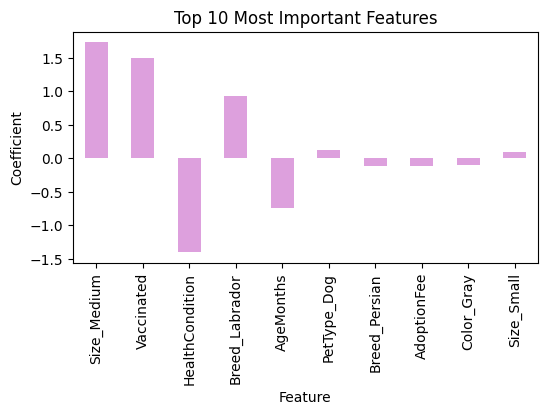

In [73]:
# Visualization of the top features
mostImportantFeatures.plot(kind='bar', x='Feature', y='Coefficient',
                           legend=False, color='plum', figsize=(6, 3))
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Top 10 Most Important Features')
plt.show()

# Decision Tree Model

In [74]:
# Create the model
DecTree_model = DecisionTreeClassifier(random_state=42)

# Train the model
DecTree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [82]:
# Make predictions
DecTree_pred = DecTree_model.predict(X_test)

# Accuracy results
accuracy_score(y_test, DecTree_pred)

0.8930348258706468

The accuracy of the decision tree model is about 89%, which indicates its high accuracy, but its not as high as I would like it to be.

In [77]:
# Decision Tree Classification Report
print(classification_report(y_test, DecTree_pred))
confusion_matrix(y_test, DecTree_pred)

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       270
           1       0.81      0.88      0.84       132

    accuracy                           0.89       402
   macro avg       0.87      0.89      0.88       402
weighted avg       0.90      0.89      0.89       402



array([[243,  27],
       [ 16, 116]])

From the precision and recall values for classes 0 and 1, it seems that the model overall performs better when predicting pets that weren't adopted compared to pets that were. The confusion matrix for the decision tree shows that for class 0 (pets that weren't adopted), the model accurately predicted 243 pets and inaccurately predicted 27 pets as being adopted when in reality, they weren't (false positive). For class 1 (pets that were adopted), the confusion matrix shows that the decision tree model accurately predicted 116 pets and inaccurately predicted 16 pets as not being adopted when in reality, they were (false negative).

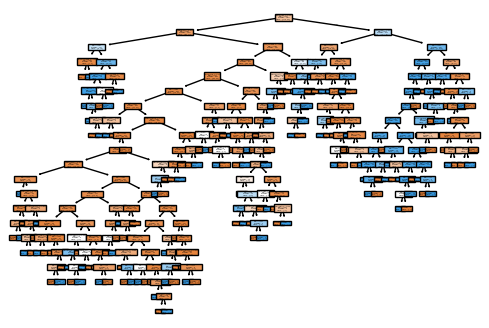

In [84]:
# Decision Tree visualization
plt.figure(figsize=(6, 4))
plot_tree(DecTree_model, filled=True, feature_names=X.columns)
plt.show()

In [79]:
# Decision Tree Feature Importance
treeFeature_importances = pd.DataFrame({'Feature': X.columns,
                                    'Importance': DecTree_model.feature_importances_})
treeFeature_importances = treeFeature_importances.sort_values(by='Importance',
                                                      ascending=False)

treeFeature_importances.head(10)

,Feature,Importance
20,Size_Medium,0.202397
2,Vaccinated,0.184271
3,HealthCondition,0.182648
0,AgeMonths,0.164027
10,Breed_Labrador,0.090848
5,AdoptionFee,0.045397
1,WeightKg,0.044887
4,TimeInShelterDays,0.040523
7,PetType_Cat,0.008593
21,Size_Small,0.007863


Similar to the logistic regression model, the decision tree model predicted a medium sized pet to be the most desirable for adoption likelihood and overall, the results are pretty similar. However, there are some differences such as a pet's weight being ranked much higher in the decision tree model compared to the logistic regression model, where the weight is not in the top 10 most influential factors.

## Logistic Regression vs. Decision Tree

In [80]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, DecTree_pred))

Logistic Regression Accuracy: 0.9079601990049752
Decision Tree Accuracy: 0.8930348258706468


The logistic regression model and the decision tree model both achieved high accuracy scores, indicating their strong performances. In overall accuracy, the logistic regression model was slightly higher and it also produced fewer false positives. Although the decision tree model was lightly less accurate overall, it produced a higher recall score for adopted pets, meaning it was better at identifying pets that were actually adopted. Unfortunately, it did produce more false positives. Overall, the logistic regression model had a more balanced and consistent performance, while the decision tree model had a better performance in predicting adopted pets.

# Discussion

Overall, both models show that medium sized pets have the highest likelihood of being adopted. Fully grown pets who are not medium sized cannot change their size, so shelters should look at other factors to see how they can improve the likelihood of those pets being adopted. For example, the second highest factor in both models is a pet's vaccination status and the third highest is a pet's health condition. Vaccinated pets have a higher adoption likelihood and pets who are in poor health condition have a negative correlation with adoption likelihood. This suggests that shelters should work on having their pets vaccinated and the should maintain all pets in good health condition, especially those pets who are not medium sized. This way, these pets may have a higher chance of being adopted. Pets who cannot physically achieve certain desirable traits, should have their other desirable traits emphasized or improved.

In this project, the variables and data used in determining the most influential factors in pet adoption centered around the pets themselves and their circumstances in the shelter. However, the project did not take into account the factors outside shelters that may affect pet adoption, such as shelter location, human lifestyles, and economic constraints. To those who may want to further explore infuential factors in pet adoptions, they should take outside factors into consideration.

# References
Feature Importance in Logistic Regression Models:
https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-in-logistic-regression-models/


Classification Report and Confusion Matrix:
https://www.geeksforgeeks.org/machine-learning/compute-classification-report-and-confusion-matrix-in-python/

Decision Tree:
https://www.geeksforgeeks.org/machine-learning/decision-tree-implementation-python/

Original Dataset:
https://www.kaggle.com/datasets/rabieelkharoua/predict-pet-adoption-status-dataset


Git Repo:
https://github.com/gcastellanos1/CSC108-MATH80-Repo

This project can be shared with future classes.